# Clustertree Segmentation QC
Clustering stability comparison across Mesmer segmentation variants using clustree + UMAP.


In [1]:
import spatialdata as sd
from pathlib import Path

zarr_paths = sorted(Path(".").glob("*.zarr"))
print("Found zarr stores:", [str(p) for p in zarr_paths])

# Load the first available zarr
sdata = sd.SpatialData.read(str(zarr_paths[0]))
sdata

Found zarr stores: ['reg001_X01_Y01_Z11.zarr', 'reg002_X01_Y01_Z10.zarr', 'reg003_X01_Y01_Z08.zarr']


no parent found for <ome_zarr.reader.Label object at 0x11d804850>: None
no parent found for <ome_zarr.reader.Label object at 0x11d80b810>: None
no parent found for <ome_zarr.reader.Label object at 0x11d7e7090>: None
no parent found for <ome_zarr.reader.Label object at 0x11d816310>: None
no parent found for <ome_zarr.reader.Label object at 0x11d814410>: None
no parent found for <ome_zarr.reader.Label object at 0x11d821c10>: None


SpatialData object, with associated Zarr store: /Users/friedrichpreusser/Desktop/code/scverse_proteomics_hackathon/colon/reg001_X01_Y01_Z11.zarr
├── Images
│     └── 'reg001_X01_Y01_Z11_image': DataArray[cyx] (92, 1440, 1920)
└── Labels
      ├── 'reg001_X01_Y01_Z11_labels': DataArray[yx] (1440, 1920)
      ├── 'reg001_X01_Y01_Z11_labels_hf': DataArray[yx] (1440, 1920)
      ├── 'reg001_X01_Y01_Z11_labels_rot90': DataArray[yx] (1440, 1920)
      ├── 'reg001_X01_Y01_Z11_labels_rot180': DataArray[yx] (1440, 1920)
      ├── 'reg001_X01_Y01_Z11_labels_rot270': DataArray[yx] (1440, 1920)
      └── 'reg001_X01_Y01_Z11_labels_vf': DataArray[yx] (1440, 1920)
with coordinate systems:
    ▸ 'global', with elements:
        reg001_X01_Y01_Z11_image (Images), reg001_X01_Y01_Z11_labels (Labels), reg001_X01_Y01_Z11_labels_hf (Labels), reg001_X01_Y01_Z11_labels_rot90 (Labels), reg001_X01_Y01_Z11_labels_rot180 (Labels), reg001_X01_Y01_Z11_labels_rot270 (Labels), reg001_X01_Y01_Z11_labels_vf (Labels)

In [2]:

# Aggregate mean intensities per cell for each segmentation variant.
# Produces `stem` (str) and `tables` (dict[variant -> AnnData]) used by the clustertree cell.

import pandas as pd
import anndata as ad
from scipy.stats import zscore

img_key = list(sdata.images.keys())[0]
stem = img_key.removesuffix("_image")

WORKING_VARIANTS = ["normal", "rot180", "hf", "vf"]

tables = {}

for variant in WORKING_VARIANTS:
    lbl_k = f"{stem}_labels" + (f"_{variant}" if variant != "normal" else "")
    agg = sdata.aggregate(values=img_key, by=lbl_k, agg_func="mean")
    t = agg["table"]
    t.var_names = t.var_names.str.replace("_mean$", "", regex=True)

    e = pd.DataFrame(
        t.X.toarray() if hasattr(t.X, "toarray") else t.X,
        columns=t.var_names,
    )
    p99 = e.quantile(0.99)
    e = e.clip(upper=p99, axis=1)
    e_z = e.apply(zscore, axis=0)

    adata = ad.AnnData(X=e.values, var=pd.DataFrame(index=e.columns))
    adata.var_names_make_unique()
    adata.layers["zscore"] = e_z.values
    adata.uns["variant"] = variant
    adata.uns["stem"] = stem
    tables[variant] = adata
    print(f"{variant}: {adata.n_obs} cells x {adata.n_vars} channels")



/Users/friedrichpreusser/Desktop/code/scverse_proteomics_hackathon/mcmicro/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1798: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/friedrichpreusser/Desktop/code/scverse_proteomics_hackathon/mcmicro/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1798: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


normal: 1216 cells x 92 channels


/Users/friedrichpreusser/Desktop/code/scverse_proteomics_hackathon/mcmicro/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1798: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/friedrichpreusser/Desktop/code/scverse_proteomics_hackathon/mcmicro/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1798: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


rot180: 1369 cells x 92 channels


/Users/friedrichpreusser/Desktop/code/scverse_proteomics_hackathon/mcmicro/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1798: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/friedrichpreusser/Desktop/code/scverse_proteomics_hackathon/mcmicro/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1798: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


hf: 1224 cells x 92 channels
vf: 1328 cells x 92 channels


/Users/friedrichpreusser/Desktop/code/scverse_proteomics_hackathon/mcmicro/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1798: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/friedrichpreusser/Desktop/code/scverse_proteomics_hackathon/mcmicro/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1798: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Processing 'normal' ...
  normal  res=0.1  ->  2 clusters
  normal  res=0.2  ->  3 clusters
  normal  res=0.4  ->  5 clusters
  normal  res=0.6  ->  6 clusters
  normal  res=0.8  ->  8 clusters
  normal  res=1.0  ->  9 clusters

Processing 'rot180' ...
  rot180  res=0.1  ->  2 clusters
  rot180  res=0.2  ->  4 clusters
  rot180  res=0.4  ->  6 clusters
  rot180  res=0.6  ->  8 clusters
  rot180  res=0.8  ->  9 clusters
  rot180  res=1.0  ->  10 clusters

Building clustree figures ...


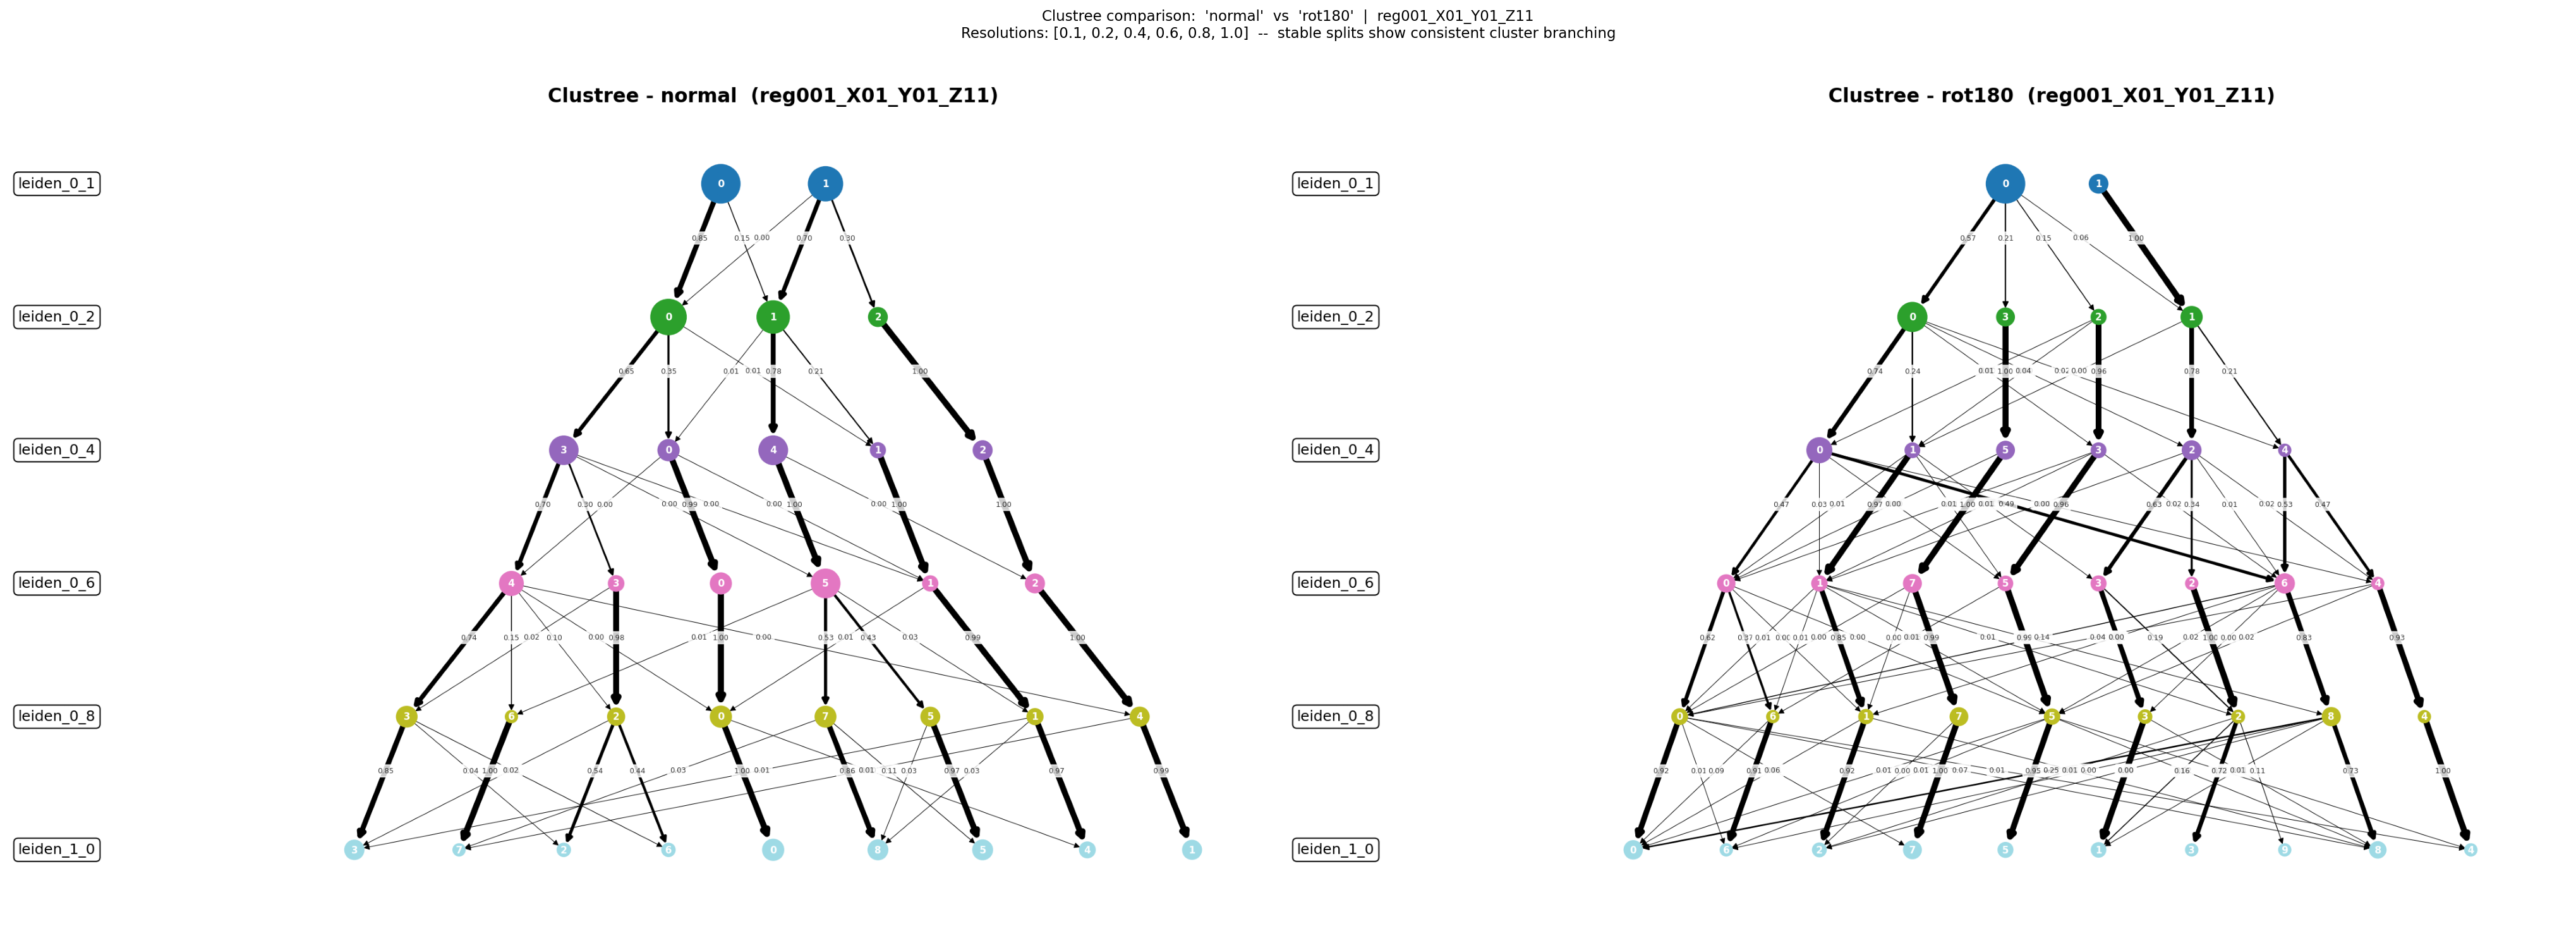

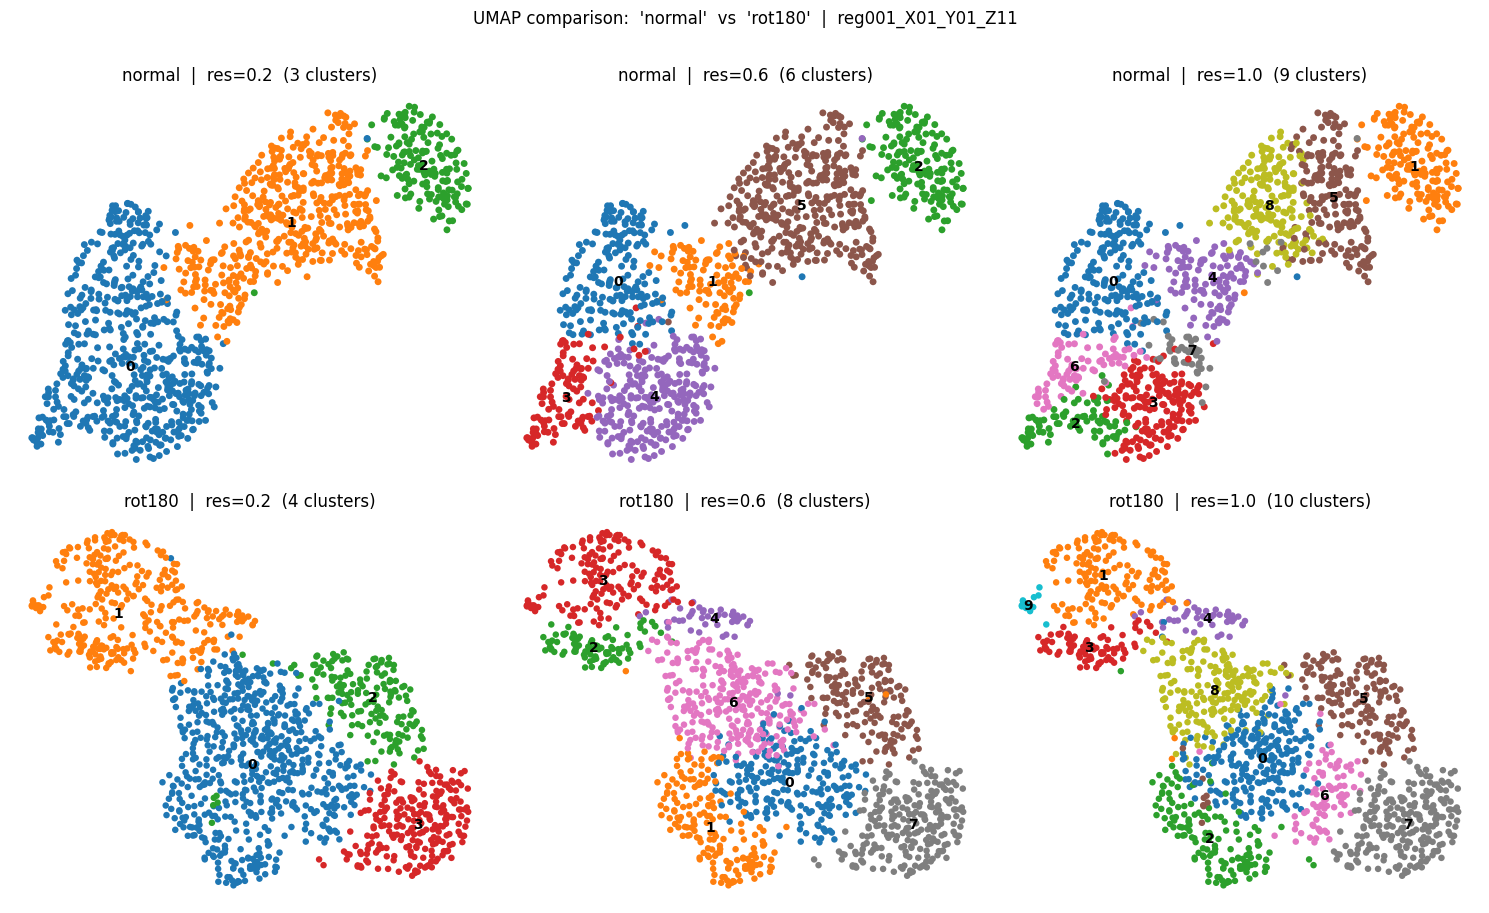

In [3]:

# Clustree + UMAP: clustering stability across resolutions for two segmentation variants
# Requires the aggregation cell above to have been run (populates `tables` and `stem`).
#
# Layout:
#   Row 1 — Clustrees side by side (stable splits = consistent branching)
#   Row 2 — UMAPs at three resolutions for each variant (2 rows x 3 cols grid)

import io
import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
from pyclustree import clustree

VARIANT_A = "normal"
VARIANT_B = "rot180"
RESOLUTIONS = [0.1, 0.2, 0.4, 0.6, 0.8, 1.0]
UMAP_RESOLUTIONS = [0.2, 0.6, 1.0]  # subset shown in UMAP grid


def preprocess_and_cluster(adata_src, variant, resolutions):
    """Normalize, PCA, KNN, UMAP, then sweep Leiden. Returns (adata, cluster_keys)."""
    adata = adata_src.copy()
    adata.layers["counts"] = adata.X.copy()
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    sc.tl.pca(adata)
    sc.pp.neighbors(adata)
    sc.tl.umap(adata)

    cluster_keys = []
    for res in resolutions:
        key = f"leiden_{str(res).replace('.', '_')}"
        sc.tl.leiden(adata, resolution=res, key_added=key, flavor="igraph", n_iterations=2)
        cluster_keys.append(key)
        n = adata.obs[key].nunique()
        print(f"  {variant}  res={res:.1f}  ->  {n} clusters")
    return adata, cluster_keys


def make_clustree_fig(adata, cluster_keys, variant):
    # y_spacing=6.0 prevents the figure from being squished vertically
    return clustree(
        adata,
        cluster_keys,
        title=f"Clustree - {variant}  ({stem})",
        show_fraction=True,
        y_spacing=6.0,
    )


def fig_to_tight_array(fig):
    """Render a matplotlib figure to an RGBA numpy array."""
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=150, bbox_inches="tight")
    buf.seek(0)
    arr = plt.imread(buf)
    buf.close()
    plt.close(fig)
    return arr


# ----- Run preprocessing + clustering -----
print(f"Processing '{VARIANT_A}' ...")
adata_a, keys_a = preprocess_and_cluster(tables[VARIANT_A], VARIANT_A, RESOLUTIONS)

print(f"\nProcessing '{VARIANT_B}' ...")
adata_b, keys_b = preprocess_and_cluster(tables[VARIANT_B], VARIANT_B, RESOLUTIONS)

# ----- Clustree comparison -----
print("\nBuilding clustree figures ...")
fig_ct_a = make_clustree_fig(adata_a, keys_a, VARIANT_A)
fig_ct_b = make_clustree_fig(adata_b, keys_b, VARIANT_B)

arr_a = fig_to_tight_array(fig_ct_a)
arr_b = fig_to_tight_array(fig_ct_b)

# Pad shorter image so heights match, then hstack
h_a, h_b = arr_a.shape[0], arr_b.shape[0]
if h_a < h_b:
    pad = np.ones((h_b - h_a, arr_a.shape[1], arr_a.shape[2]), dtype=arr_a.dtype)
    arr_a = np.vstack([arr_a, pad])
elif h_b < h_a:
    pad = np.ones((h_a - h_b, arr_b.shape[1], arr_b.shape[2]), dtype=arr_b.dtype)
    arr_b = np.vstack([arr_b, pad])

combined_ct = np.hstack([arr_a, arr_b])
h_px, w_px = combined_ct.shape[:2]

fig_ct, ax_ct = plt.subplots(figsize=(w_px / 150, h_px / 150), dpi=150)
ax_ct.imshow(combined_ct)
ax_ct.axis("off")
fig_ct.suptitle(
    f"Clustree comparison:  '{VARIANT_A}'  vs  '{VARIANT_B}'  |  {stem}\n"
    f"Resolutions: {RESOLUTIONS}  --  stable splits show consistent cluster branching",
    fontsize=11, y=1.01,
)
plt.tight_layout()
plt.show()

# ----- UMAP grid -----
# 2 rows (variant) x 3 cols (resolution)
umap_keys = [f"leiden_{str(r).replace('.', '_')}" for r in UMAP_RESOLUTIONS]
adatas = [(adata_a, VARIANT_A), (adata_b, VARIANT_B)]

n_res = len(UMAP_RESOLUTIONS)
fig_um, axes = plt.subplots(2, n_res, figsize=(5 * n_res, 9))

for row, (adata_v, variant) in enumerate(adatas):
    for col, (res, key) in enumerate(zip(UMAP_RESOLUTIONS, umap_keys)):
        ax = axes[row, col]
        n_clusters = adata_v.obs[key].nunique()
        sc.pl.umap(
            adata_v,
            color=key,
            ax=ax,
            show=False,
            title=f"{variant}  |  res={res}  ({n_clusters} clusters)",
            legend_loc="on data" if n_clusters <= 12 else "right margin",
            frameon=False,
        )
        if col > 0:
            ax.set_ylabel("")

fig_um.suptitle(
    f"UMAP comparison:  '{VARIANT_A}'  vs  '{VARIANT_B}'  |  {stem}",
    fontsize=12, y=1.01,
)
plt.tight_layout()
plt.show()
